In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [5]:
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

In [6]:
df = pd.read_csv('../data/Sample - Superstore.csv', encoding='latin-1')


In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter

In [8]:
print("Data loaded successfully")
print("Shape:", df.shape)

Data loaded successfully
Shape: (9994, 24)


In [9]:
monthly_sales = df.groupby(
    ['Year', 'Month', 'Quarter', 'Category', 'Region']
).agg(
    Total_Sales=('Sales', 'sum'),
    Avg_Discount=('Discount', 'mean'),
    Total_Quantity=('Quantity', 'sum'),
    Avg_Profit=('Profit', 'mean'),
    Order_Count=('Order ID', 'count')
).reset_index()

In [10]:
print("=== AGGREGATED DATASET ===")
print("Shape:", monthly_sales.shape)
print("\nFirst 5 rows:")
monthly_sales.head()

=== AGGREGATED DATASET ===
Shape: (573, 10)

First 5 rows:


,Year,Month,Quarter,Category,Region,Total_Sales,Avg_Discount,Total_Quantity,Avg_Profit,Order_Count
0,2014,1,1,Furniture,Central,506.358,0.150000,11,5.230875,4
1,2014,1,1,Furniture,East,199.004,0.233333,12,-7.201933,3
2,2014,1,1,Furniture,South,4378.728,0.025000,32,141.282100,8
3,2014,1,1,Furniture,West,1158.435,0.240000,15,-64.821600,5
4,2014,1,1,Office Supplies,Central,1002.348,0.156250,48,5.488544,16


In [11]:
le_category = LabelEncoder()
le_region = LabelEncoder()

monthly_sales['Category_Encoded'] = le_category.fit_transform(monthly_sales['Category'])
monthly_sales['Region_Encoded'] = le_region.fit_transform(monthly_sales['Region'])


In [12]:
print("=== CATEGORY ENCODING ===")
for i, label in enumerate(le_category.classes_):
    print(f"  {label} → {i}")

print("\n=== REGION ENCODING ===")
for i, label in enumerate(le_region.classes_):
    print(f"  {label} → {i}")

=== CATEGORY ENCODING ===
  Furniture → 0
  Office Supplies → 1
  Technology → 2

=== REGION ENCODING ===
  Central → 0
  East → 1
  South → 2
  West → 3


In [13]:
print("\n=== FINAL FEATURE SET ===")
features = ['Year', 'Month', 'Quarter', 'Category_Encoded', 
            'Region_Encoded', 'Avg_Discount', 'Total_Quantity']
print("Features (X):", features)
print("Target (y):   Total_Sales")


=== FINAL FEATURE SET ===
Features (X): ['Year', 'Month', 'Quarter', 'Category_Encoded', 'Region_Encoded', 'Avg_Discount', 'Total_Quantity']
Target (y):   Total_Sales


In [14]:
X = monthly_sales[features]
y = monthly_sales['Total_Sales']

print("\nX shape:", X.shape)
print("y shape:", y.shape)


X shape: (573, 7)
y shape: (573,)


In [15]:
train = monthly_sales[monthly_sales['Year'] <= 2016]
test = monthly_sales[monthly_sales['Year'] == 2017]

X_train = train[features]
y_train = train['Total_Sales']

X_test = test[features]
y_test = test['Total_Sales']

print("=== TRAIN/TEST SPLIT ===")
print(f"Training set: {X_train.shape[0]} rows (2014–2016)")
print(f"Testing set:  {X_test.shape[0]} rows (2017)")
print(f"\nTrain %: {X_train.shape[0]/len(monthly_sales)*100:.1f}%")
print(f"Test  %: {X_test.shape[0]/len(monthly_sales)*100:.1f}%")

=== TRAIN/TEST SPLIT ===
Training set: 429 rows (2014–2016)
Testing set:  144 rows (2017)

Train %: 74.9%
Test  %: 25.1%


In [16]:

# Model 1: Random Forest

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

# Model 2: Linear Regression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n=== {name} ===")
    print(f"  MAE  (Mean Absolute Error):  ${mae:,.2f}")
    print(f"  RMSE (Root Mean Sq. Error):  ${rmse:,.2f}")
    print(f"  R²   (Accuracy Score):        {r2:.4f}")
    return mae, rmse, r2

rf_mae, rf_rmse, rf_r2 = evaluate_model("Random Forest", y_test, rf_predictions)
lr_mae, lr_rmse, lr_r2 = evaluate_model("Linear Regression", y_test, lr_predictions)
    


=== Random Forest ===
  MAE  (Mean Absolute Error):  $1,867.88
  RMSE (Root Mean Sq. Error):  $3,023.19
  R²   (Accuracy Score):        0.4723

=== Linear Regression ===
  MAE  (Mean Absolute Error):  $2,305.88
  RMSE (Root Mean Sq. Error):  $3,585.12
  R²   (Accuracy Score):        0.2579


In [31]:

monthly_sales = monthly_sales.sort_values(
    ['Category', 'Region', 'Year', 'Month']
).reset_index(drop=True)

monthly_sales['Sales_Lag1'] = monthly_sales.groupby(
    ['Category', 'Region']
)['Total_Sales'].shift(1)

monthly_sales['Sales_Lag2'] = monthly_sales.groupby(
    ['Category', 'Region']
)['Total_Sales'].shift(2)

monthly_sales['Sales_Lag3'] = monthly_sales.groupby(
    ['Category', 'Region']
)['Total_Sales'].shift(3)

# Rolling 3-month average
monthly_sales['Sales_Rolling3'] = monthly_sales.groupby(
    ['Category', 'Region']
)['Total_Sales'].transform(
    lambda x: x.shift(1).rolling(window=3).mean()
)


monthly_sales['Is_Q4'] = (monthly_sales['Quarter'] == 4).astype(int)

monthly_sales_ml = monthly_sales.dropna().reset_index(drop=True)

print("=== ENHANCED FEATURE SET ===")
print(f"Rows after adding lag features: {len(monthly_sales_ml)}")


features_v2 = ['Year', 'Month', 'Quarter', 'Is_Q4',
               'Category_Encoded', 'Region_Encoded',
               'Avg_Discount', 'Total_Quantity',
               'Sales_Lag1', 'Sales_Lag2', 'Sales_Lag3',
               'Sales_Rolling3']

print(f"Number of features: {len(features_v2)}")
print(f"\nFeatures: {features_v2}")

=== ENHANCED FEATURE SET ===
Rows after adding lag features: 537
Number of features: 12

Features: ['Year', 'Month', 'Quarter', 'Is_Q4', 'Category_Encoded', 'Region_Encoded', 'Avg_Discount', 'Total_Quantity', 'Sales_Lag1', 'Sales_Lag2', 'Sales_Lag3', 'Sales_Rolling3']


In [32]:

train_v2 = monthly_sales_ml[monthly_sales_ml['Year'] <= 2016]
test_v2  = monthly_sales_ml[monthly_sales_ml['Year'] == 2017]

X_train_v2 = train_v2[features_v2]
y_train_v2 = train_v2['Total_Sales']

X_test_v2  = test_v2[features_v2]
y_test_v2  = test_v2['Total_Sales']


rf_v2 = RandomForestRegressor(n_estimators=200, random_state=42)
rf_v2.fit(X_train_v2, y_train_v2)
rf_v2_predictions = rf_v2.predict(X_test_v2)


rf_v2_mae, rf_v2_rmse, rf_v2_r2 = evaluate_model(
    "Random Forest v2 (Enhanced)", y_test_v2, rf_v2_predictions
)


print("\n=== MODEL IMPROVEMENT SUMMARY ===")
print(f"{'Metric':<10} {'v1 (Basic)':>15} {'v2 (Enhanced)':>15} {'Improvement':>15}")
print("-" * 58)
print(f"{'MAE':<10} ${rf_mae:>13,.2f} ${rf_v2_mae:>13,.2f} ${rf_mae - rf_v2_mae:>13,.2f}")
print(f"{'RMSE':<10} ${rf_rmse:>13,.2f} ${rf_v2_rmse:>13,.2f} ${rf_rmse - rf_v2_rmse:>13,.2f}")
print(f"{'R²':<10} {rf_r2:>15.4f} {rf_v2_r2:>15.4f} {rf_v2_r2 - rf_r2:>15.4f}")


=== Random Forest v2 (Enhanced) ===
  MAE  (Mean Absolute Error):  $2,050.99
  RMSE (Root Mean Sq. Error):  $3,185.23
  R²   (Accuracy Score):        0.4142

=== MODEL IMPROVEMENT SUMMARY ===
Metric          v1 (Basic)   v2 (Enhanced)     Improvement
----------------------------------------------------------
MAE        $     1,867.88 $     2,050.99 $      -183.12
RMSE       $     3,023.19 $     3,185.23 $      -162.03
R²                  0.4723          0.4142         -0.0581


In [33]:
final_model = RandomForestRegressor(n_estimators=200, random_state=42)
final_model.fit(X_train, y_train)
final_predictions = final_model.predict(X_test)

final_mae, final_rmse, final_r2 = evaluate_model(
    "Final Model (Random Forest)", y_test, final_predictions
)


print("\n=== FEATURE IMPORTANCE ===")
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)

for _, row in importance_df.iterrows():
    bar = '█' * int(row['Importance'] * 50)
    print(f"  {row['Feature']:<25} {bar} {row['Importance']:.4f}")


=== Final Model (Random Forest) ===
  MAE  (Mean Absolute Error):  $1,859.69
  RMSE (Root Mean Sq. Error):  $3,004.34
  R²   (Accuracy Score):        0.4788

=== FEATURE IMPORTANCE ===
  Total_Quantity            ████████████████████ 0.4119
  Month                     █████████ 0.1857
  Avg_Discount              ████████ 0.1723
  Category_Encoded          █████ 0.1043
  Region_Encoded            ███ 0.0649
  Year                      ██ 0.0446
  Quarter                    0.0162


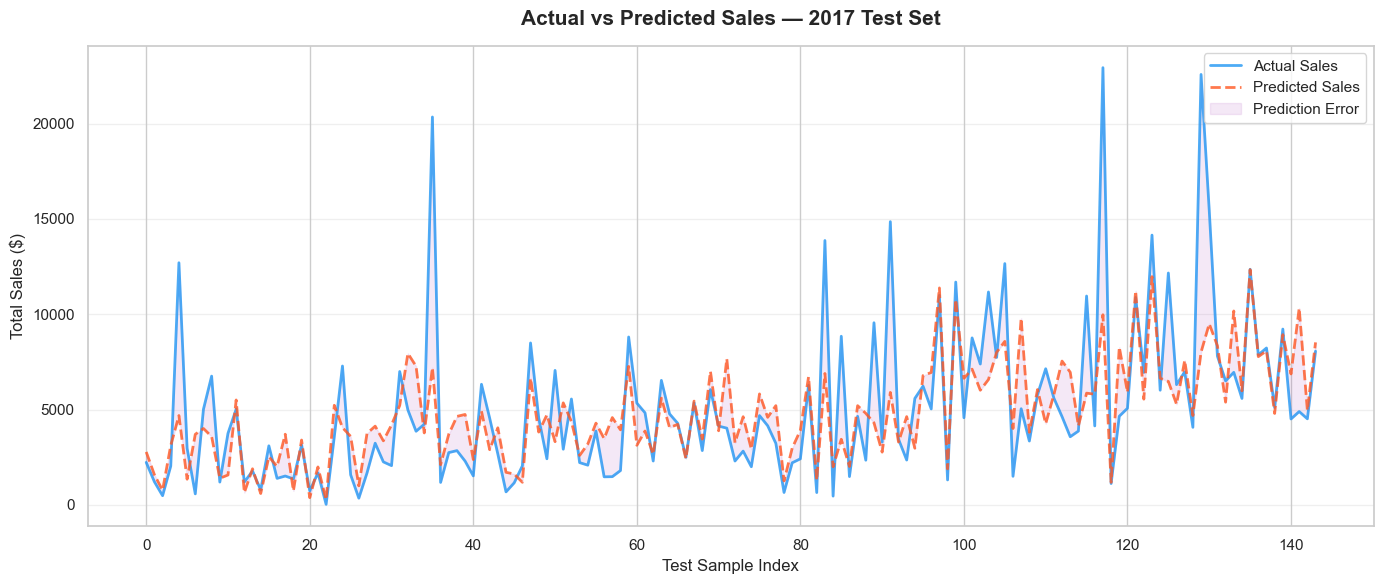

Chart saved to reports/


In [34]:

plt.figure(figsize=(14, 6))

x_axis = range(len(y_test))

plt.plot(x_axis, y_test.values, 
         label='Actual Sales', color='#2196F3', 
         linewidth=2, alpha=0.8)

plt.plot(x_axis, final_predictions, 
         label='Predicted Sales', color='#FF5722', 
         linewidth=2, linestyle='--', alpha=0.8)

plt.fill_between(x_axis, y_test.values, final_predictions,
                 alpha=0.1, color='#9C27B0', label='Prediction Error')

plt.title('Actual vs Predicted Sales — 2017 Test Set', 
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Test Sample Index', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/04_actual_vs_predicted.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/")